# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Energy Usage Prediction**

---

| | |
|---|---|
| **Full name** | Shivalika Karan Bora |
| **Student ID** | 25096080 |
| **Email** | BoraS3@cardiff.ac.uk |
| **Role** | Time Series Patterns & LightGBM Model |

## Notebook Summary

1. Time-Series Exploratory Analysis (hourly, monthly, weekday/weekend, heatmaps)
2. Lag and Rolling-Window Feature Engineering (leakage-aware shifted rolling)
3. LightGBM and XGBoost training and `RandomizedSearchCV` tuning
4. Best-Model Selection, Prediction Saving, and Feature Importance

**Notes on this notebook.** The time-series exploratory analysis, the leakage-aware lag and rolling-window features, and the LightGBM / XGBoost training and tuning workflow were authored by Shivalika. During integration, Zahra added per-meter RMSLE breakdowns and adjusted output paths (commit `92f24b0`) and refreshed final outputs after the project-wide rerun. Wahid contributed a variable-name cleanup pass.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
# ===============================
# 1. LOAD MERGED DATA
# ===============================
df = pd.read_csv("../data_processed/merged_train.csv")

In [30]:
# Quick check
print(df.head())

   building_id  meter            timestamp  meter_reading  site_id  \
0            0      0  2016-01-01 00:00:00            0.0        0   
1            1      0  2016-01-01 00:00:00            0.0        0   
2            2      0  2016-01-01 00:00:00            0.0        0   
3            3      0  2016-01-01 00:00:00            0.0        0   
4            4      0  2016-01-01 00:00:00            0.0        0   

  primary_use  square_feet  year_built  floor_count  air_temperature  \
0   Education         7432      2008.0          NaN             25.0   
1   Education         2720      2004.0          NaN             25.0   
2   Education         5376      1991.0          NaN             25.0   
3   Education        23685      2002.0          NaN             25.0   
4   Education       116607      1975.0          NaN             25.0   

   cloud_coverage  dew_temperature  precip_depth_1_hr  sea_level_pressure  \
0             6.0             20.0                NaN              10

In [31]:
# ===============================
# 2. CONVERT TIMESTAMP
# ===============================
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [32]:
# ===============================
# 3. FEATURE ENGINEERING
# ===============================
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["month"] = df["timestamp"].dt.month

### Hourly Energy Consumption

This plot shows how energy usage varies across different hours of the day for each meter type. 
It helps in identifying peak usage hours and understanding daily consumption patterns.

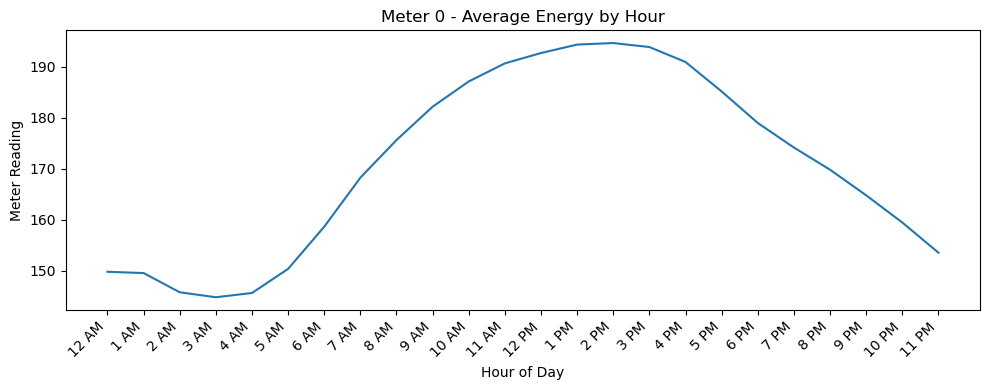

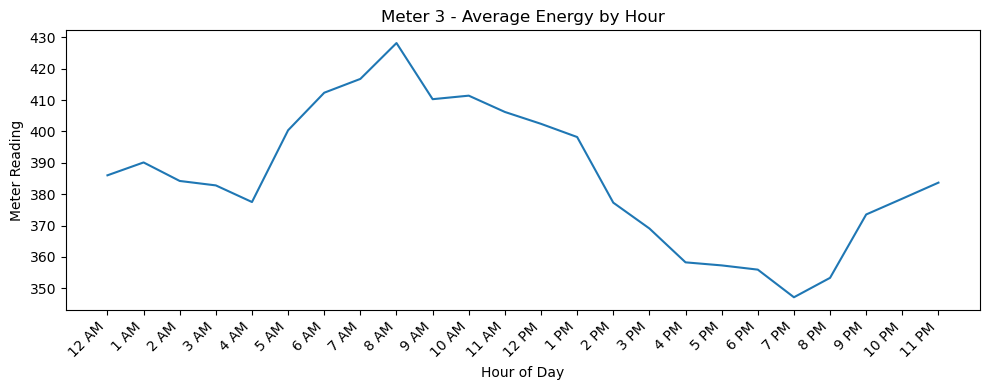

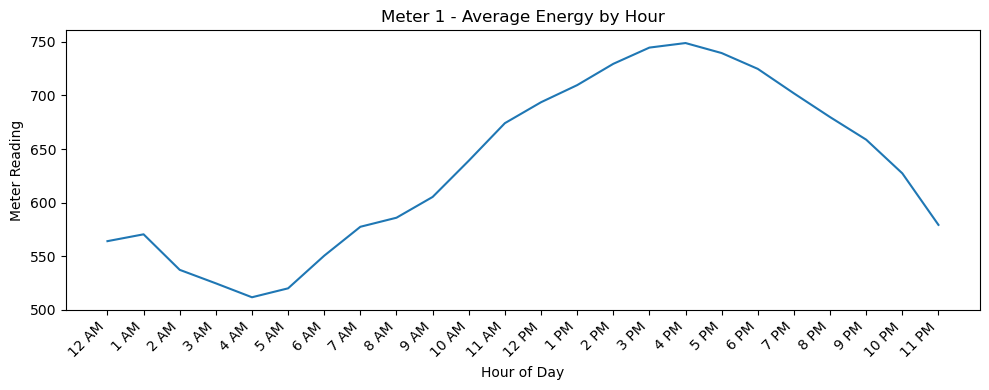

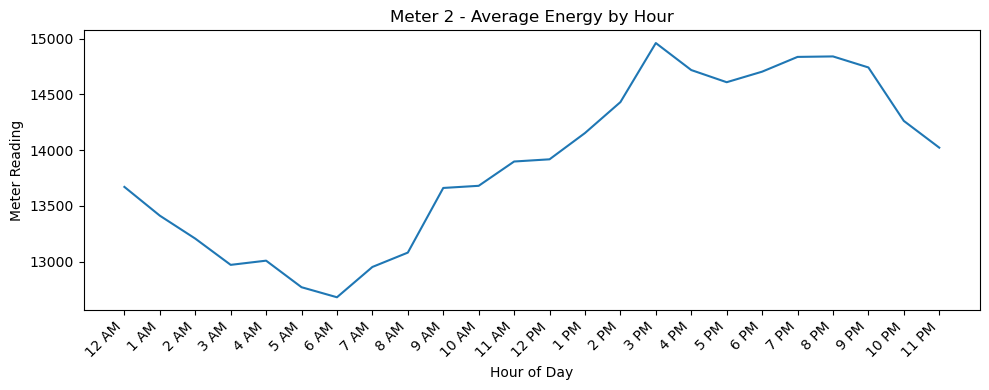

In [33]:
# ===============================
# 4. AVERAGE ENERGY BY HOUR (per meter type)
# ===============================

hour_labels = [
    "12 AM", "1 AM", "2 AM", "3 AM", "4 AM", "5 AM",
    "6 AM", "7 AM", "8 AM", "9 AM", "10 AM", "11 AM",
    "12 PM", "1 PM", "2 PM", "3 PM", "4 PM", "5 PM",
    "6 PM", "7 PM", "8 PM", "9 PM", "10 PM", "11 PM",
]

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    hourly = subset.groupby("hour")["meter_reading"].mean().reindex(range(24))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(hourly.index, hourly.values, linewidth=1.5)

    ax.set_xticks(range(24))
    ax.set_xticklabels(hour_labels, rotation=45, ha='right')
    ax.set_title(f"Meter {m} - Average Energy by Hour")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Meter Reading")

    fig.tight_layout()
    plt.show()


Observation:

Energy consumption is generally higher during daytime hours and lower during late night and early morning hours. 
This indicates that building activity significantly influences energy usage patterns.

### Monthly Energy Consumption

This plot illustrates how energy usage changes across different months of the year for each meter type. 
It helps in identifying seasonal trends in energy consumption.

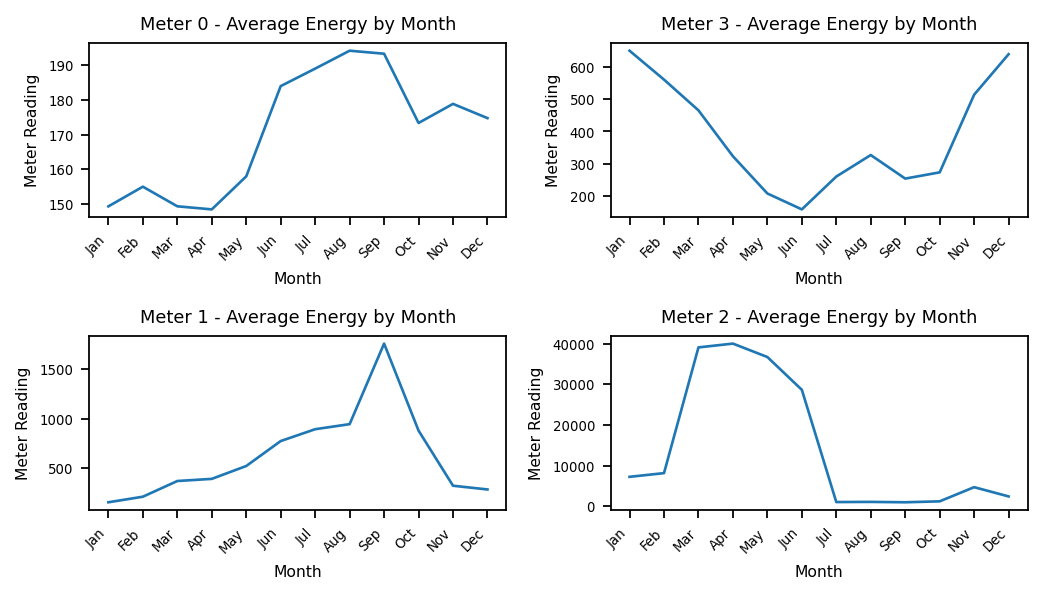

Saved to ..\docs\Report\Final Report\assets\Test3.png


In [34]:
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# ===============================
# 5. AVERAGE ENERGY BY MONTH (per meter type)
# ===============================

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
meter_order = list(df["meter"].drop_duplicates())

fig, axes = plt.subplots(2, 2, figsize=(6.6, 3.8), dpi=160)
axes = axes.ravel()

for ax, m in zip(axes, meter_order):
    subset = df[df["meter"] == m]
    monthly = subset.groupby("month")["meter_reading"].mean().reindex(range(1, 13))

    ax.plot(monthly.index, monthly.values, linewidth=1.2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=6)
    ax.set_title(f"Meter {m} - Average Energy by Month", fontsize=8)
    ax.set_xlabel("Month", fontsize=7)
    ax.set_ylabel("Meter Reading", fontsize=7)
    ax.tick_params(axis='y', labelsize=6)

for ax in axes[len(meter_order):]:
    ax.axis('off')

fig.tight_layout(pad=1.0)
fig.savefig(FINAL_REPORT_ASSETS_DIR / "Test3.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'Test3.png'}")


Observation:

Energy usage varies across months, indicating seasonal trends. 
Higher consumption in certain months may be due to increased heating or cooling demands depending on weather conditions.

### Weekday vs Weekend Energy Usage

This plot compares the average energy consumption between weekdays and weekends. 
It helps in understanding how operational patterns affect energy usage.

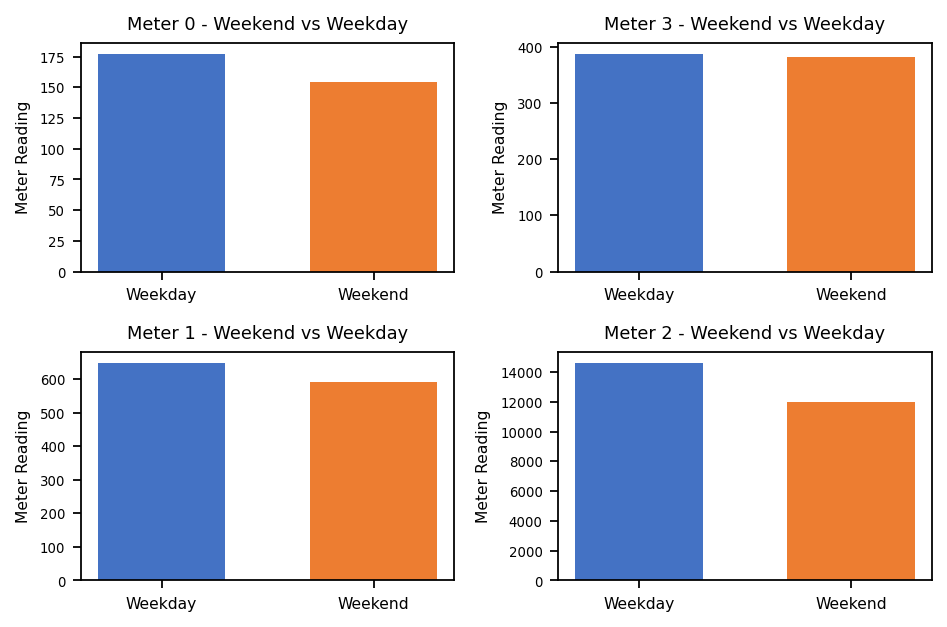

Saved to ..\docs\Report\Final Report\assets\Test4.png


In [35]:
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# ===============================
# 6. WEEKDAY vs WEEKEND
# ===============================

meter_order = list(df["meter"].drop_duplicates())

fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.0), dpi=160)
axes = axes.ravel()

for ax, m in zip(axes, meter_order):
    subset = df[df["meter"] == m]
    week = subset.groupby("is_weekend")["meter_reading"].mean().reindex([0, 1])

    ax.bar([0, 1], week.values, color=["#4472C4", "#ED7D31"], width=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Weekday", "Weekend"], fontsize=7)
    ax.set_title(f"Meter {m} - Weekend vs Weekday", fontsize=8)
    ax.set_ylabel("Meter Reading", fontsize=7)
    ax.tick_params(axis='y', labelsize=6)

for ax in axes[len(meter_order):]:
    ax.axis('off')

fig.tight_layout(pad=1.0)
fig.savefig(FINAL_REPORT_ASSETS_DIR / "Test4.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'Test4.png'}")


Observation:

Energy consumption is generally higher on weekdays compared to weekends. 
This suggests that buildings are more actively used during working days, leading to increased energy demand.

### Energy Consumption Timeline for Selected Buildings

This plot shows the energy usage trend over time for three selected buildings across the year 2016. 
It helps in understanding how energy consumption varies over time at the building level.

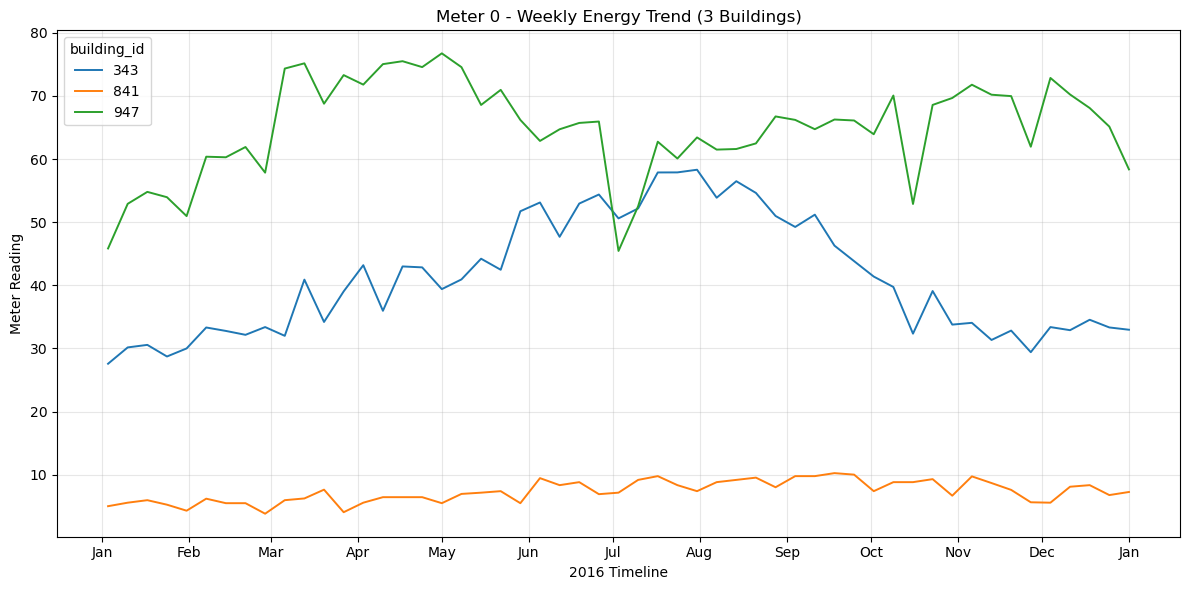

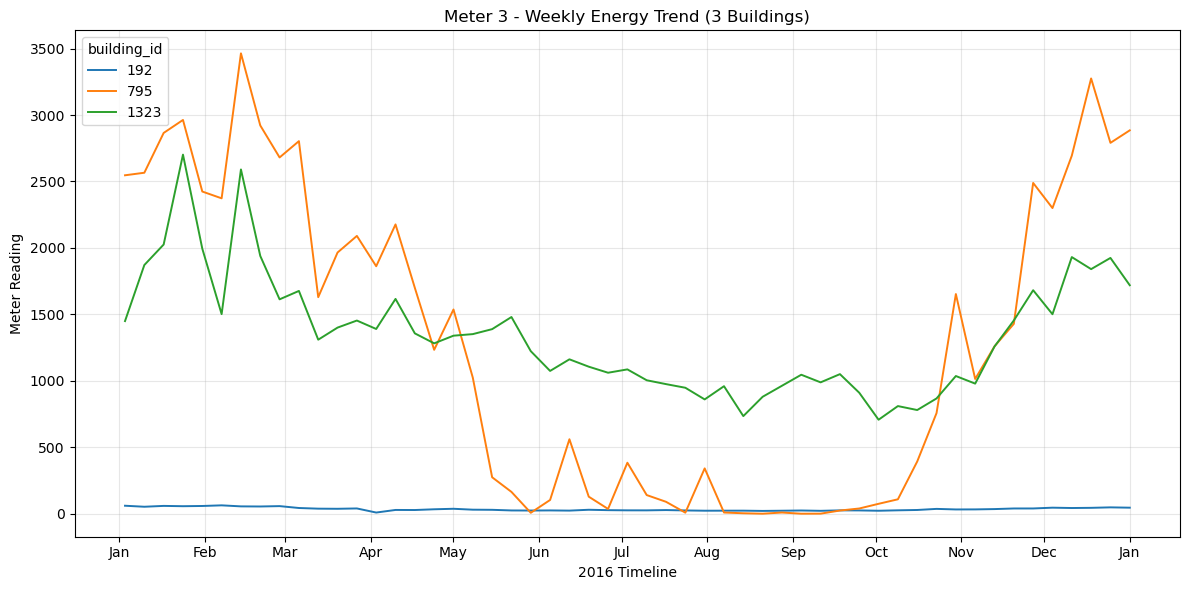

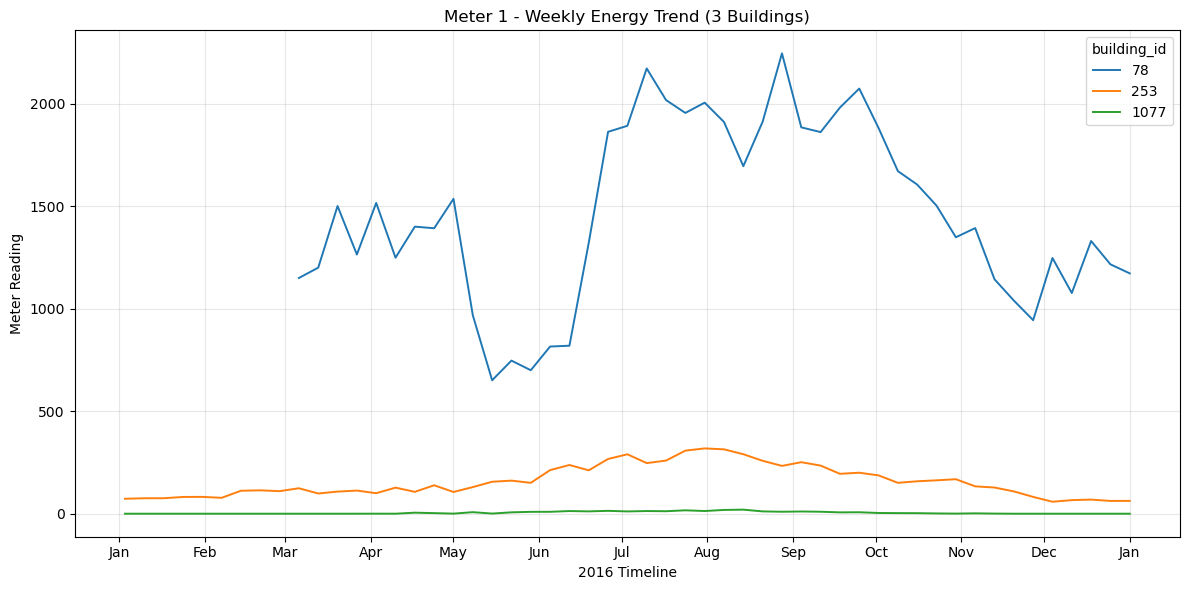

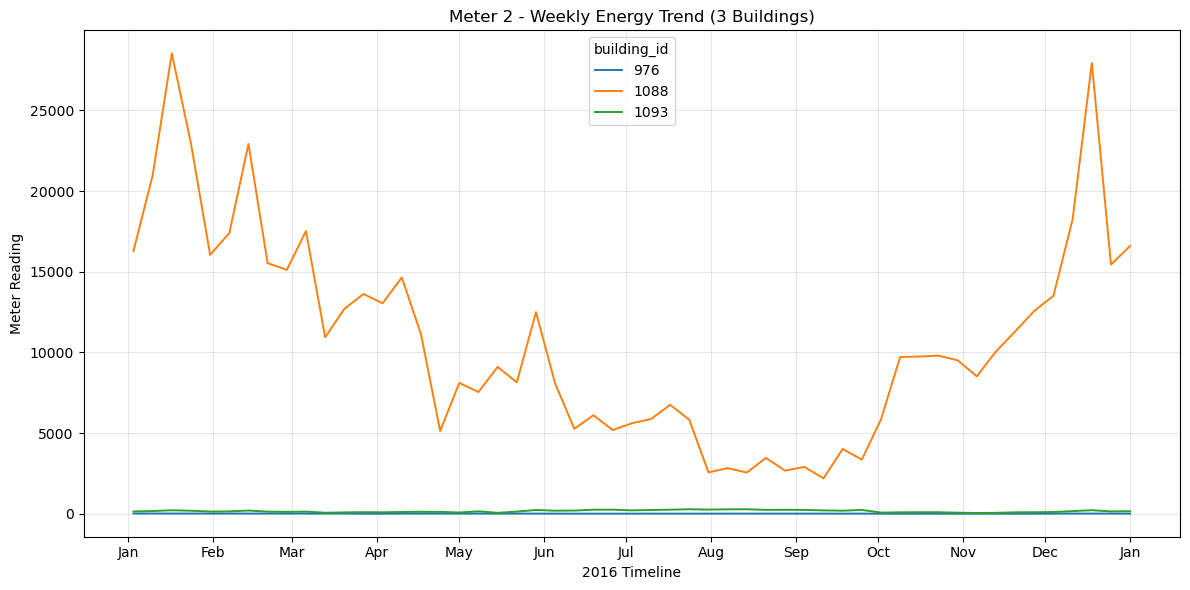

In [36]:
# ===============================
# 7. 3 BUILDINGS TIMELINE (2016)
# ===============================
import matplotlib.dates as mdates

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    if len(subset) == 0:
        continue

    sample_buildings = subset["building_id"].drop_duplicates().sample(3, random_state=42)
    subset_3 = subset[subset["building_id"].isin(sample_buildings)]

    subset_3 = subset_3.set_index("timestamp")
    subset_3 = subset_3[
        (subset_3.index >= "2016-01-01") &
        (subset_3.index < "2017-01-01")
    ]
    weekly = subset_3.groupby(["building_id"]).resample("W")["meter_reading"].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 6))
    for building_id, group in weekly.groupby("building_id"):
        ax.plot(group["timestamp"], group["meter_reading"], label=str(building_id), linewidth=1.4)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_title(f"Meter {m} - Weekly Energy Trend (3 Buildings)")
    ax.set_xlabel("2016 Timeline")
    ax.set_ylabel("Meter Reading")
    ax.legend(title="building_id")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


Observation:

The energy usage shows fluctuations over time, with some consistent patterns visible across buildings. 
Due to high-frequency variations in the data, the overall trend is more important than individual spikes. 
This indicates that energy consumption follows recurring patterns with some variability across buildings.

### Heatmap of Energy Usage (Month vs Hour)

This heatmap represents the average energy consumption across different months and hours of the day. 
It provides a combined view of both daily and seasonal patterns in energy usage.

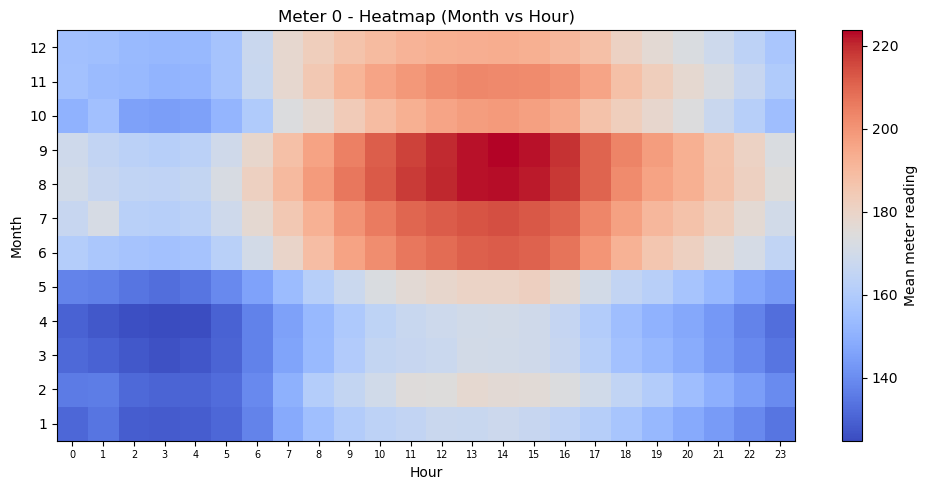

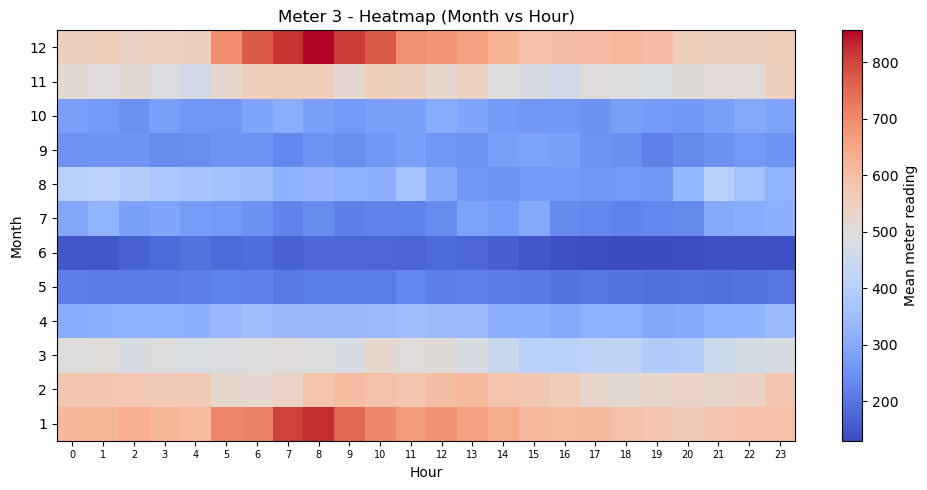

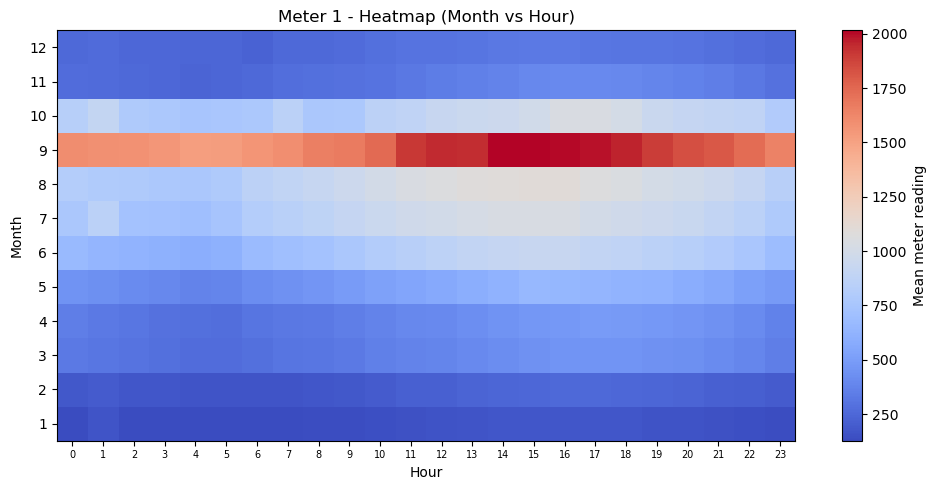

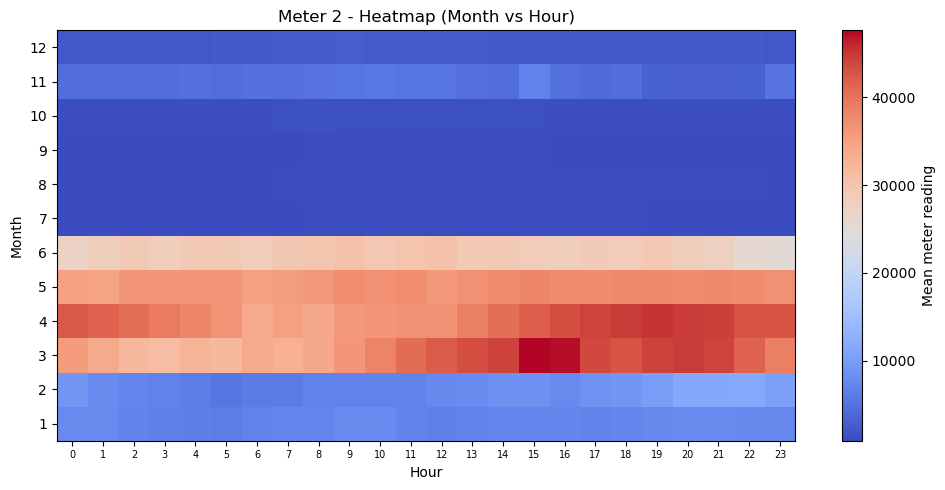

In [37]:
# ===============================
# 8. HEATMAP (Month vs Hour)
# ===============================
for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    heatmap_data = subset.pivot_table(
        values="meter_reading",
        index="month",
        columns="hour",
        aggfunc="mean"
    ).reindex(index=range(1, 13), columns=range(24))

    fig, ax = plt.subplots(figsize=(10, 5))
    image = ax.imshow(heatmap_data.values, aspect="auto", cmap="coolwarm", origin="lower")
    ax.set_title(f"Meter {m} - Heatmap (Month vs Hour)")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Month")
    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=7)
    ax.set_yticks(range(12))
    ax.set_yticklabels(range(1, 13))
    fig.colorbar(image, ax=ax, label="Mean meter reading")

    fig.tight_layout()
    plt.show()


Observation:

The heatmap shows that energy usage depends on both time of day and month. 
Certain hours and months exhibit higher consumption, indicating peak usage periods. 
This combined effect highlights the importance of temporal features in understanding energy patterns.

In [38]:
# ===============================
# 9. SUMMARY STATISTICS (OPTIONAL BUT GOOD)
# ===============================
print("\nSummary Statistics:")
print(df["meter_reading"].describe())


Summary Statistics:
count    2.021610e+07
mean     2.117121e+03
std      1.532356e+05
min      0.000000e+00
25%      1.830000e+01
50%      7.877500e+01
75%      2.679840e+02
max      2.190470e+07
Name: meter_reading, dtype: float64


Key Findings:

• Time-based features (hour, day_of_week, month) were successfully extracted from the timestamp for temporal analysis

• Hourly analysis shows that peak energy usage occurs during afternoon hours (approximately 12 PM – 4 PM), while lowest usage is observed during early morning hours (12 AM – 5 AM)

• Monthly trends show clear seasonal variation:
  o Meter 0 peaks around July–September (~180–190) and is lowest in January–March (~145–155)
  o Meter 1 shows highest usage around September (~1700–1800) and lowest in January (~150–200)
  o Meter 2 has extremely high values in March–May (~38,000–40,000) and drops significantly after June
  o Meter 3 shows higher usage at the beginning and end of the year (~600–650) and lowest around mid-year (~150–250)

• Weekday vs weekend comparison shows consistently higher energy usage on weekdays across all meters:
  o Meter 0: ~175 (weekday) vs ~155 (weekend)
  o Meter 1: ~650 vs ~600
  o Meter 2: ~14,500 vs ~12,000
  o Meter 3: ~390 vs ~380

• Weekly trend analysis (smoothed timeline) shows consistent seasonal patterns across buildings, with gradual increases and decreases rather than random noise

• Heatmap analysis (month vs hour) highlights that peak energy usage occurs during afternoon hours (12–4 PM) and specific months depending on meter type

• Significant variation exists between meter types, with Meter 2 having much higher values compared to others, so separate visualizations were used for clarity

• Overall, energy consumption is strongly influenced by temporal features such as hour, day, and month, making them important for further modelling

In [39]:
import pandas as pd
import matplotlib.pyplot as plt


In [40]:
train_path = r"../data_processed/final_train.csv"
val_path   = r"../data_processed/final_val.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(val_path)


In [41]:
print(train_df.head())
print(test_df.head())

   building_id  meter            timestamp  meter_reading  site_id  \
0          105      0  2016-01-01 00:00:00        23.3036        1   
1          106      0  2016-01-01 00:00:00         0.3746        1   
2          106      3  2016-01-01 00:00:00         0.0000        1   
3          107      0  2016-01-01 00:00:00       175.1840        1   
4          108      0  2016-01-01 00:00:00        91.2653        1   

   floor_count  missing_floor_count_flag  building_age  log_square_feet  \
0            5                         0            48        10.832181   
1            4                         0            48         8.589514   
2            4                         0            48         8.589514   
3           10                         0            11        11.487946   
4            5                         0           103        11.309352   

   use_Education  ...  relative_humidity  temp_diff_from_comfort  hour  \
0              1  ...           90.57553              

In [42]:
print("\n--- DATASET OVERVIEW ---")
print("Shape:", train_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nData Types:")
print(train_df.dtypes)


--- DATASET OVERVIEW ---
Shape: (14529655, 43)

Columns:
Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'floor_count', 'missing_floor_count_flag', 'building_age',
       'log_square_feet', 'use_Education', 'use_Entertainment/public assembly',
       'use_Food sales and service', 'use_Healthcare',
       'use_Lodging/residential', 'use_Manufacturing/industrial', 'use_Office',
       'use_Other', 'use_Parking', 'use_Public services',
       'use_Religious worship', 'use_Retail', 'use_Services',
       'use_Technology/science', 'use_Utility', 'use_Warehouse/storage',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'precip_was_missing', 'relative_humidity',
       'temp_diff_from_comfort', 'hour', 'day_of_week', 'month', 'day_of_year',
       'season', 'is_weekend', 'is_business_hours', 'log_meter_reading'],
      dtype='object')

Data Types:
building_id 

The dataset contains building-level energy readings along with temporal and environmental features.


--- TARGET DESCRIPTION ---
count    1.452966e+07
mean     2.708484e+03
std      1.783574e+05
min      0.000000e+00
25%      2.440000e+01
50%      8.642500e+01
75%      2.781975e+02
max      2.190470e+07
Name: meter_reading, dtype: float64


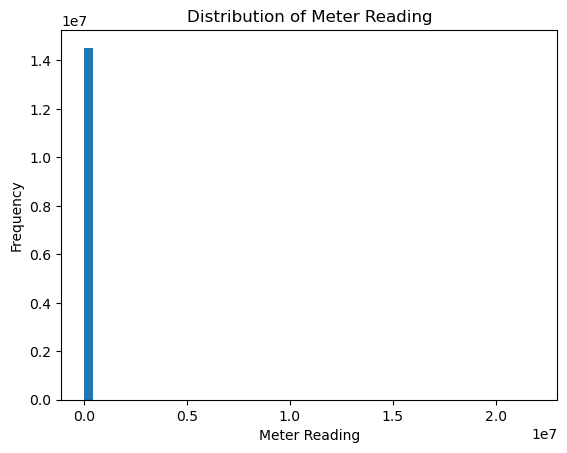

In [43]:
print("\n--- TARGET DESCRIPTION ---")
print(train_df['meter_reading'].describe())

plt.figure()
plt.hist(train_df['meter_reading'], bins=50)
plt.title("Distribution of Meter Reading")
plt.xlabel("Meter Reading")
plt.ylabel("Frequency")
plt.show()

Analyze distribution of energy consumption.

Data PreProcessing

In [44]:
# Convert timestamp to datetime
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

# Sort data for time-series correctness
train_df = train_df.sort_values(['building_id', 'meter', 'timestamp'])
test_df = test_df.sort_values(['building_id', 'meter', 'timestamp'])
test_df = test_df.sort_values(['building_id', 'meter', 'timestamp'])

print("\n--- TIMESTAMP CHECK ---")
print(train_df[['timestamp']].head())
print(test_df[['timestamp']].head())
print(test_df[['timestamp']].head())


--- TIMESTAMP CHECK ---
                  timestamp
6494078 2016-05-20 00:00:00
6496112 2016-05-20 01:00:00
6498144 2016-05-20 02:00:00
6500177 2016-05-20 03:00:00
6502213 2016-05-20 04:00:00
               timestamp
0    2016-11-01 00:00:00
2050 2016-11-01 01:00:00
4099 2016-11-01 02:00:00
6149 2016-11-01 03:00:00
8199 2016-11-01 04:00:00
               timestamp
0    2016-11-01 00:00:00
2050 2016-11-01 01:00:00
4099 2016-11-01 02:00:00
6149 2016-11-01 03:00:00
8199 2016-11-01 04:00:00


Timestamps are converted into datetime format and data is sorted chronologically to ensure correct time-series processing.

Lag Features

Lag features (24h, 72h, 168h) are created to capture past consumption patterns.

Rolling features capture trends and variability over time.

A shift operation is applied before rolling to avoid data leakage.

The dataset is sorted to maintain temporal order.

In [45]:
def add_lag_features(df):
    df = df.sort_values(['building_id', 'meter', 'timestamp']).copy()
    df['lag_24h'] = df.groupby(['building_id','meter'])['meter_reading'].shift(24)
    df['lag_72h'] = df.groupby(['building_id','meter'])['meter_reading'].shift(72)
    df['lag_168h'] = df.groupby(['building_id','meter'])['meter_reading'].shift(168)
    return df

train_df = add_lag_features(train_df)
test_df = add_lag_features(test_df)


print(train_df[['meter_reading','lag_24h','lag_72h','lag_168h']].head(10))
print(test_df[['meter_reading','lag_24h','lag_72h','lag_168h']].head(10))



         meter_reading  lag_24h  lag_72h  lag_168h
6494078            0.0      NaN      NaN       NaN
6496112            0.0      NaN      NaN       NaN
6498144            0.0      NaN      NaN       NaN
6500177            0.0      NaN      NaN       NaN
6502213            0.0      NaN      NaN       NaN
6504248            0.0      NaN      NaN       NaN
6506282            0.0      NaN      NaN       NaN
6508318            0.0      NaN      NaN       NaN
6510355            0.0      NaN      NaN       NaN
6512392            0.0      NaN      NaN       NaN
       meter_reading  lag_24h  lag_72h  lag_168h
0            96.9235      NaN      NaN       NaN
2050         96.1045      NaN      NaN       NaN
4099         95.0124      NaN      NaN       NaN
6149         94.7394      NaN      NaN       NaN
8199         94.1933      NaN      NaN       NaN
10249        95.5584      NaN      NaN       NaN
12299        96.3775      NaN      NaN       NaN
14349        93.3742      NaN      NaN       Na

Lag features capture past values of energy consumption:

24h → previous day
72h → 3 days
168h → 1 week

These help the model learn temporal dependencies.

Rolling Features (Avoiding Data Leakage)

In [46]:
def add_rolling_features(df):
    df = df.sort_values(['building_id', 'meter', 'timestamp']).copy()
    grouped = df.groupby(['building_id','meter'])['meter_reading']
    df['rolling_mean_24h'] = grouped.transform(lambda x: x.shift(1).rolling(24).mean())
    df['rolling_std_24h'] = grouped.transform(lambda x: x.shift(1).rolling(24).std())
    df['rolling_mean_168h'] = grouped.transform(lambda x: x.shift(1).rolling(168).mean())
    return df

train_df = add_rolling_features(train_df)
test_df = add_rolling_features(test_df)

print("\n--- ROLLING FEATURES SAMPLE ---")
print(train_df[['rolling_mean_24h','rolling_std_24h']].head(10))
print(test_df[['rolling_mean_24h','rolling_std_24h']].head(10))


--- ROLLING FEATURES SAMPLE ---
         rolling_mean_24h  rolling_std_24h
6494078               NaN              NaN
6496112               NaN              NaN
6498144               NaN              NaN
6500177               NaN              NaN
6502213               NaN              NaN
6504248               NaN              NaN
6506282               NaN              NaN
6508318               NaN              NaN
6510355               NaN              NaN
6512392               NaN              NaN
       rolling_mean_24h  rolling_std_24h
0                   NaN              NaN
2050                NaN              NaN
4099                NaN              NaN
6149                NaN              NaN
8199                NaN              NaN
10249               NaN              NaN
12299               NaN              NaN
14349               NaN              NaN
16399               NaN              NaN
18449               NaN              NaN


Rolling features capture trends and variability over time.
A shift is applied before rolling to prevent data leakage (future data influencing predictions).

In [47]:
sample1 = train_df[train_df['building_id'] == 105]
sample2 = test_df[test_df['building_id'] == 105]


print(sample1[['meter_reading','rolling_mean_24h']].head(30))
print(sample2[['meter_reading','rolling_mean_24h']].head(30))

       meter_reading  rolling_mean_24h
0            23.3036               NaN
1990         45.6071               NaN
3975         45.6071               NaN
5964         45.1071               NaN
7950         45.6071               NaN
9936         45.1071               NaN
11921        45.1071               NaN
13904        43.6071               NaN
15888        46.1071               NaN
17872        47.6071               NaN
19857        47.6071               NaN
21844        48.1071               NaN
23831        48.6071               NaN
25818        48.1071               NaN
27806        48.6071               NaN
29796        49.1071               NaN
31782        49.1071               NaN
33772        49.1071               NaN
35761        48.1071               NaN
37748        47.6071               NaN
39734        48.6071               NaN
41721        46.6071               NaN
43707        45.6071               NaN
45694        45.1071               NaN
47682        37.9286     

Handle Missing Values

In [48]:
feature_cols = [
    'lag_24h','lag_72h','lag_168h',
    'rolling_mean_24h','rolling_std_24h','rolling_mean_168h'
]

required_history_cols = [
    'lag_24h','lag_168h','rolling_mean_24h','rolling_std_24h'
]

train_df = train_df.dropna(subset=required_history_cols)
test_df = test_df.dropna(subset=required_history_cols)

print("\n--- MISSING VALUES AFTER HANDLING ---")
print("Train:")
print(train_df[feature_cols].isnull().sum())
print("\nValidation:")
print(test_df[feature_cols].isnull().sum())


--- MISSING VALUES AFTER HANDLING ---
Train:
lag_24h              0
lag_72h              0
lag_168h             0
rolling_mean_24h     0
rolling_std_24h      0
rolling_mean_168h    0
dtype: int64

Validation:
lag_24h              0
lag_72h              0
lag_168h             0
rolling_mean_24h     0
rolling_std_24h      0
rolling_mean_168h    0
dtype: int64


Missing values occur due to shifting and rolling operations.
These are handled using zero imputation to maintain dataset consistency.

In [49]:
print("\n--- FEATURE CHECK (NON-ZERO VALUES) FOR TRAIN DATA ---")
print(train_df[['meter_reading','lag_24h','rolling_mean_24h']].iloc[200:210])


print("\n--- FEATURE CHECK (NON-ZERO VALUES) FOR VALIDATION DATA ---")
print(test_df[['meter_reading','lag_24h','rolling_mean_24h']].iloc[200:210])


--- FEATURE CHECK (NON-ZERO VALUES) FOR TRAIN DATA ---
         meter_reading  lag_24h  rolling_mean_24h
7241997       131.0520  131.052        136.716792
7244023       129.4130  145.249        136.716792
7246052       132.9630  163.268        136.056958
7248086        34.1280  137.058        134.794250
7250119        17.4735  126.956        130.505500
7252152       131.3250  160.811        125.943729
7254185       132.4170  146.614        124.715146
7256217       134.0550  128.321        124.123604
7258251       130.7790  130.506        124.362521
7260285       130.5060  131.598        124.373896

--- FEATURE CHECK (NON-ZERO VALUES) FOR VALIDATION DATA ---
        meter_reading  lag_24h  rolling_mean_24h
747824        58.7002  63.3416         65.855683
749814        89.5519  88.7328         65.662292
751802        80.8151  87.0947         65.696421
753790        79.4500  82.9993         65.434771
755779        78.6309  81.0882         65.286883
757768        78.0849  78.0849         

Verify features are correctly computed.

Validation Checks

In [50]:
print("\n--- CHECK SORTING FOR TRAIN DATA ---")
print(train_df[['building_id','meter','timestamp']].head())

print("\n--- MISSING VALUES FOR TRAIN DATA ---")
print(train_df[feature_cols].isnull().sum())


print("\n--- CHECK SORTING FOR VALIDATION DATA ---")
print(test_df[['building_id','meter','timestamp']].head())

print("\n--- MISSING VALUES FOR VALIDATION DATA ---")
print(test_df[feature_cols].isnull().sum())



--- CHECK SORTING FOR TRAIN DATA ---
         building_id  meter           timestamp
6834673            1      0 2016-05-27 00:00:00
6836708            1      0 2016-05-27 01:00:00
6838743            1      0 2016-05-27 02:00:00
6840778            1      0 2016-05-27 03:00:00
6842812            1      0 2016-05-27 04:00:00

--- MISSING VALUES FOR TRAIN DATA ---
lag_24h              0
lag_72h              0
lag_168h             0
rolling_mean_24h     0
rolling_std_24h      0
rolling_mean_168h    0
dtype: int64

--- CHECK SORTING FOR VALIDATION DATA ---
        building_id  meter           timestamp
342413            1      0 2016-11-08 00:00:00
344462            1      0 2016-11-08 01:00:00
346510            1      0 2016-11-08 02:00:00
348560            1      0 2016-11-08 03:00:00
350609            1      0 2016-11-08 04:00:00

--- MISSING VALUES FOR VALIDATION DATA ---
lag_24h              0
lag_72h              0
lag_168h             0
rolling_mean_24h     0
rolling_std_24h      0


Validation ensures:

Data is properly sorted
No missing values remain in engineered features

CORRELATION ANALYSIS

In [51]:
corr1 = train_df[['meter_reading','lag_24h','lag_168h','rolling_mean_24h']].corr()
corr2 = test_df[['meter_reading','lag_24h','lag_168h','rolling_mean_24h']].corr()

print("\n--- CORRELATION MATRIX FOR TRAIN DATA ---")
print(corr1)
print("\n--- CORRELATION MATRIX FOR VALIDATION DATA ---")
print(corr2)


--- CORRELATION MATRIX FOR TRAIN DATA ---
                  meter_reading   lag_24h  lag_168h  rolling_mean_24h
meter_reading          1.000000  0.913123  0.764047          0.960573
lag_24h                0.913123  1.000000  0.777961          0.964347
lag_168h               0.764047  0.777961  1.000000          0.787569
rolling_mean_24h       0.960573  0.964347  0.787569          1.000000

--- CORRELATION MATRIX FOR VALIDATION DATA ---
                  meter_reading   lag_24h  lag_168h  rolling_mean_24h
meter_reading          1.000000  0.428657  0.001290          0.779454
lag_24h                0.428657  1.000000  0.001326          0.806309
lag_168h               0.001290  0.001326  1.000000          0.001459
rolling_mean_24h       0.779454  0.806309  0.001459          1.000000


Check relationship between engineered features and target.

Lag Feature Visualization

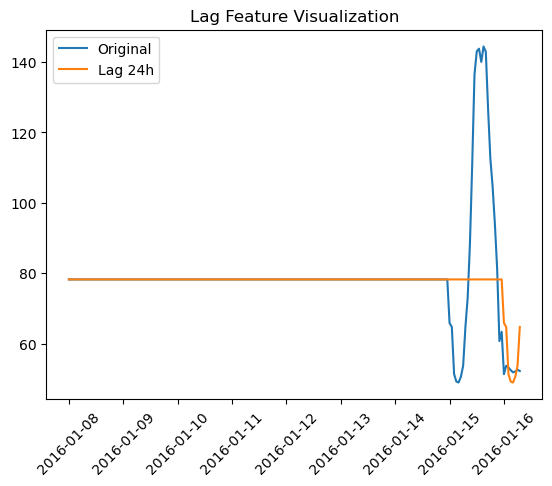

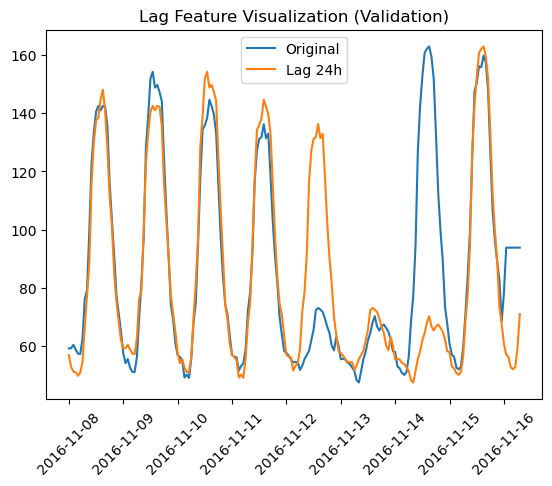

In [52]:
sample1 = train_df[train_df['building_id'] == 105].head(200)
sample2 = test_df[test_df['building_id'] == 105].head(200)

plt.figure()
plt.plot(sample1['timestamp'], sample1['meter_reading'], label='Original')
plt.plot(sample1['timestamp'], sample1['lag_24h'], label='Lag 24h')
plt.legend()
plt.title("Lag Feature Visualization")
plt.xticks(rotation=45)
plt.show()

plt.plot(sample2['timestamp'], sample2['meter_reading'], label='Original')
plt.plot(sample2['timestamp'], sample2['lag_24h'], label='Lag 24h')
plt.legend()
plt.title("Lag Feature Visualization (Validation)")
plt.xticks(rotation=45)
plt.show()




Visualization helps verify feature behavior.
The lag feature clearly represents past values of the original time series.

Rolling Mean Trend

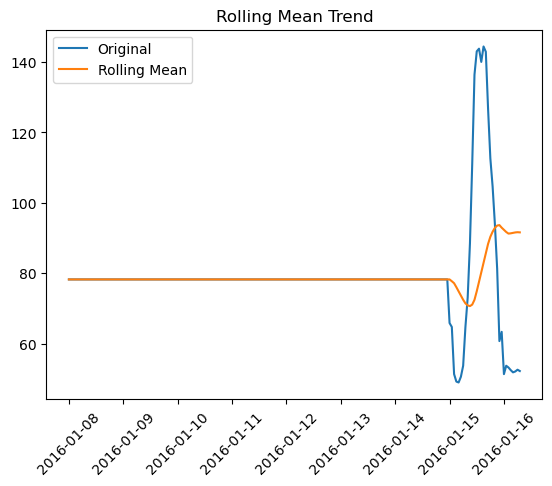

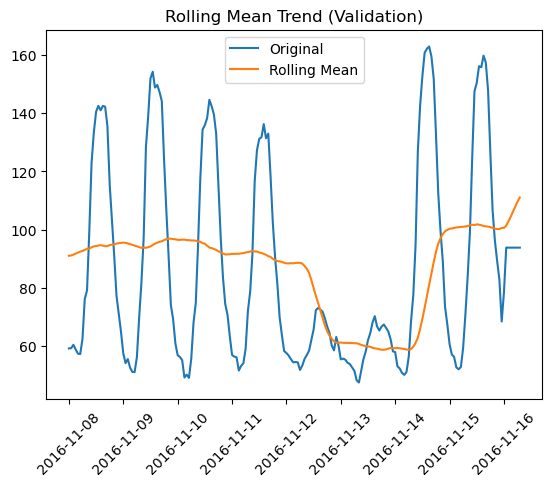

In [53]:
plt.figure()
plt.plot(sample1['timestamp'], sample1['meter_reading'], label='Original')
plt.plot(sample1['timestamp'], sample1['rolling_mean_24h'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Trend")
plt.xticks(rotation=45)
plt.show()


plt.plot(sample2['timestamp'], sample2['meter_reading'], label='Original')
plt.plot(sample2['timestamp'], sample2['rolling_mean_24h'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Trend (Validation)")    
plt.xticks(rotation=45)
plt.show()


In [54]:
# ==============================
# SAVE DATA
# ==============================

import os

output_path = "../data_processed"

# create folder if not exists
os.makedirs(output_path, exist_ok=True)

train_df.to_csv(output_path + "/final_train_with_features.csv", index=False)
test_df.to_csv(output_path + "/final_test_with_features.csv", index=False)

# NOTE: final_test_with_features.csv contains the held-out validation period
# loaded from final_val.csv above. The unused Kaggle test set is not part of
# the final modelling workflow.

print("Files saved.")

Files saved.


INSIGHTS:

1. Energy consumption exhibits strong temporal patterns, as seen from the effectiveness of lag features.

2. Lag features such as 24-hour and 168-hour lags show that energy usage follows daily and weekly cycles.

3. Rolling statistics (mean and standard deviation) help capture trends and smooth short-term fluctuations in energy consumption.

4. The use of shift before rolling ensures that only past data is used, preventing data leakage and making the features reliable for prediction.

5. Initial missing values are generated due to insufficient historical data for lag and rolling calculations, and these were handled appropriately.

6. Correlation analysis indicates that lag features are strongly related to the target variable, confirming their usefulness for modeling.

7. Overall, feature engineering significantly improves the dataset by incorporating time-based dependencies, making it more suitable for accurate energy consumption forecasting.

In [2]:
import pandas as pd
train_df = pd.read_csv("../data_processed/final_train_with_features.csv")
test_df   = pd.read_csv("../data_processed/final_test_with_features.csv")


Define Final Feature List - FEATURE SELECTION

In [3]:
drop_cols = ["timestamp", "row_id"] if "row_id" in train_df.columns else ["timestamp"]

feature_cols = [
    col for col in train_df.columns
    if col not in drop_cols + ["meter_reading", "log_meter_reading"]
]

X_train = train_df[feature_cols]
y_train = train_df["meter_reading"]

X_test = test_df[feature_cols]
y_test = test_df["meter_reading"]

print("Leakage check:", "log_meter_reading" in X_train.columns)

Leakage check: False


Log Transform Target

In [4]:
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_test)

In [5]:
drop_cols_test = ["timestamp", "row_id"] if "row_id" in test_df.columns else ["timestamp"]
X_test = test_df.drop(columns=drop_cols_test, errors='ignore')

#  Check mismatch BEFORE fixing
print("Missing in test:", set(X_train.columns) - set(X_test.columns))
print("Extra in test:", set(X_test.columns) - set(X_train.columns))

# Add missing columns as NaN
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = np.nan

#  Ensure same order
X_test = X_test[X_train.columns]

Missing in test: set()
Extra in test: {'log_meter_reading', 'meter_reading'}


Train LightGBM Model

In [6]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.308410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3907
[LightGBM] [Info] Number of data points in the train set: 14183013, number of used features: 46
[LightGBM] [Info] Start training from score 4.363338


LGBMRegressor(learning_rate=0.05, n_estimators=500, n_jobs=-1, random_state=42)

We train a LightGBM regression model using the processed training data to learn patterns in energy consumption.

Predict on Validation Set

In [7]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

Compute RMSLE

In [8]:
import sys
import os
sys.path.append(os.path.abspath(".."))


from shared.metrics import rmsle

rmsle_1 = rmsle(y_test, y_pred)
print("RMSLE Model 1:", rmsle_1)

RMSLE Model 1: 0.516223735292755


We compute RMSLE to evaluate model performance, which is suitable for skewed data like energy usage.

Second Model (Hyperparameter Tuning)

In [9]:
model2 = lgb.LGBMRegressor(
    n_estimators=150,        
    learning_rate=0.1,       
    num_leaves=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1                
)

model2.fit(X_train, y_train_log)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.596519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3907
[LightGBM] [Info] Number of data points in the train set: 14183013, number of used features: 46
[LightGBM] [Info] Start training from score 4.363338


LGBMRegressor(max_depth=10, n_estimators=150, n_jobs=-1, num_leaves=50,
              random_state=42)

In [10]:
y_pred_log_2 = model2.predict(X_test)
y_pred_2 = np.expm1(y_pred_log_2)

rmsle_2 = rmsle(y_test, y_pred_2)
print("RMSLE Model 2:", rmsle_2)

RMSLE Model 2: 0.5175106628052775


LightGBM tuning

In [11]:
from sklearn.model_selection import RandomizedSearchCV
import time

param_grid = {
    "n_estimators":      [500, 1000, 1500],
    "learning_rate":     [0.03, 0.05, 0.07],
    "num_leaves":        [31, 63, 127],
    "min_child_samples": [20, 50, 100],
    "reg_alpha":         [0, 0.1, 1.0],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_grid,
    n_iter=15, cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1, random_state=42, verbose=1,
)

t0 = time.time()
X_sample = X_train.sample(frac=0.30, random_state=42)
y_sample = y_train_log.loc[X_sample.index]
lgb_search.fit(X_sample, y_sample)
print(f"Best params: {lgb_search.best_params_}")
print(f"Search time: {(time.time()-t0)/60:.1f} min")

t1 = time.time()
best_lgb = lgb.LGBMRegressor(**lgb_search.best_params_,
                             random_state=42, n_jobs=-1, verbose=-1)
best_lgb.fit(X_train, y_train_log)
print(f"Refit time: {(time.time()-t1)/60:.1f} min")

y_pred_tuned = np.expm1(best_lgb.predict(X_test))
rmsle_tuned  = rmsle(y_test, y_pred_tuned)
print(f"Tuned LightGBM RMSLE: {rmsle_tuned:.4f}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'reg_alpha': 1.0, 'num_leaves': 127, 'n_estimators': 1500, 'min_child_samples': 50, 'learning_rate': 0.07}
Search time: 184.3 min
Refit time: 15.7 min
Tuned LightGBM RMSLE: 0.5085


In [12]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


XGBoost


In [13]:
#  XGBoost Model
import sys
print(sys.executable)

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_log)

y_pred_xgb = np.expm1(xgb_model.predict(X_test))
rmsle_xgb = rmsle(y_test, y_pred_xgb)

print("XGBoost RMSLE:", rmsle_xgb)

C:\ProgramData\anaconda3\python.exe
XGBoost RMSLE: 0.5186289452467369


XGBoost Tunning

In [14]:
# from sklearn.model_selection import RandomizedSearchCV
# import xgboost as xgb

# param_grid_xgb = {
#     "n_estimators": [100, 300],
#     "learning_rate": [0.01, 0.05],
#     "max_depth": [4, 6, 8],
# }

# search_xgb = RandomizedSearchCV(
#     xgb.XGBRegressor(random_state=42, n_jobs=-1),
#     param_grid_xgb,
#     n_iter=3,
#     cv=3,
#     scoring="neg_mean_squared_error",
#     n_jobs=-1
# )

# search_xgb.fit(X_train, y_train_log)

# best_xgb = search_xgb.best_estimator_

# # Evaluate
# y_pred_xgb_tuned = np.expm1(best_xgb.predict(X_val))
# rmsle_xgb_tuned = rmsle(y_val, y_pred_xgb_tuned)

# print("Tuned XGBoost RMSLE:", rmsle_xgb_tuned)

from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05],
    "max_depth": [4, 6],
}

search_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=1),
    param_grid_xgb,
    n_iter=2,
    cv=2,
    n_jobs=1
)

#  USE SAMPLE
X_sample = X_train.sample(frac=0.05, random_state=42)
y_sample = y_train_log.loc[X_sample.index]

search_xgb.fit(X_sample, y_sample)

best_xgb = search_xgb.best_estimator_

# Evaluate
y_pred_xgb_tuned = np.expm1(best_xgb.predict(X_test))
rmsle_xgb_tuned = rmsle(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost RMSLE:", rmsle_xgb_tuned)

Tuned XGBoost RMSLE: 0.5265350924874667


FINAL COMPARISON


In [15]:
print("\nFinal Comparison:")
print("LightGBM Base:", rmsle_1)
print("LightGBM Model 2:", rmsle_2)
print("LightGBM Tuned:", rmsle_tuned)
print("XGBoost Base:", rmsle_xgb)
print("XGBoost Tuned:", rmsle_xgb_tuned)


Final Comparison:
LightGBM Base: 0.516223735292755
LightGBM Model 2: 0.5175106628052775
LightGBM Tuned: 0.5085453666733929
XGBoost Base: 0.5186289452467369
XGBoost Tuned: 0.5265350924874667


Selecting best model

In [16]:
candidates = [
    ('LightGBM base',  model,    rmsle_1),
    ('LightGBM alt',   model2,   rmsle_2),
    ('LightGBM tuned', best_lgb, rmsle_tuned),
]
best_label, best_model, best_rmsle = min(candidates, key=lambda c: c[2])

for label, _, r in candidates:
    print(f"{label:<18}: {r:.4f}{'  <-- saving' if r == best_rmsle else ''}")
print(f"Selected: {best_label}")


LightGBM base     : 0.5162
LightGBM alt      : 0.5175
LightGBM tuned    : 0.5085  <-- saving
Selected: LightGBM tuned


Test Prediction

In [17]:
test_preds_log = best_model.predict(X_test)
test_preds = np.expm1(test_preds_log)
print("Test predictions generated:", len(test_preds))


Test predictions generated: 2614072


Saving Submission

In [18]:
import sys
import os
sys.path.append(os.path.abspath(".."))

os.makedirs("outputs", exist_ok=True)

if "row_id" in test_df.columns:
    submission = test_df[["row_id"]].copy()
    submission["meter_reading"] = test_preds
    submission.to_csv("outputs/test_predictions.csv", index=False)
    print("Test predictions saved")
else:
    print("Skipping Kaggle submission — test_df is the validation set (no row_id column).")

Skipping Kaggle submission — test_df is the validation set (no row_id column).


Saving Model

In [19]:
import pickle

with open("outputs/lightgbm_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully")


Model saved successfully


Feature Importance

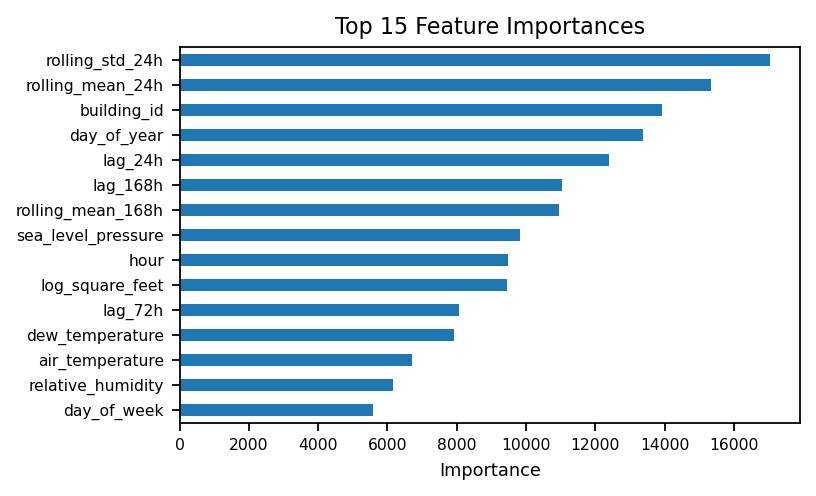

Loaded model from ..\outputs\lightgbm_model.pkl
Saved to ..\docs\Report\Final Report\assets\feat_imp.png


In [27]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

model_path = Path("../outputs/lightgbm_model.pkl")
if not model_path.exists():
    raise FileNotFoundError(f"Saved LightGBM model not found: {model_path}")

model = joblib.load(model_path)

def get_model_feature_names(fitted_model):
    for attr in ("feature_names_in_", "feature_name_", "feature_names_"):
        if hasattr(fitted_model, attr):
            names = getattr(fitted_model, attr)
            names = names() if callable(names) else names
            if names is not None and len(names) > 0:
                return list(names)
    raise AttributeError("The saved model does not expose feature names.")

feature_names = get_model_feature_names(model)
importances = getattr(model, "feature_importances_", None)
if importances is None:
    raise AttributeError("The saved model does not expose feature_importances_.")
if len(importances) != len(feature_names):
    raise ValueError(f"Feature importance length ({len(importances)}) does not match feature names ({len(feature_names)}).")

importance = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(5.2, 3.2), dpi=160)
importance[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 15 Feature Importances", fontsize=10)
ax.set_xlabel("Importance", fontsize=8)
ax.tick_params(axis='both', labelsize=7)

fig.tight_layout()
fig.savefig(FINAL_REPORT_ASSETS_DIR / "feat_imp.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Loaded model from {model_path}")
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'feat_imp.png'}")


**INSIGHTS:**

1. The baseline LightGBM model achieved an RMSLE of approximately 0.516 on the shared validation set.

2. The second LightGBM configuration was slightly worse at approximately 0.518.

3. The RandomizedSearchCV-tuned LightGBM model improved validation RMSLE to approximately 0.5085 and was selected as the saved `lightgbm_model.pkl`.

4. The tuned result shows that broader hyperparameter search improved performance compared with the original hand-picked configurations.

5. RMSLE remained the evaluation metric throughout, keeping the LightGBM results directly comparable with the other trained models.


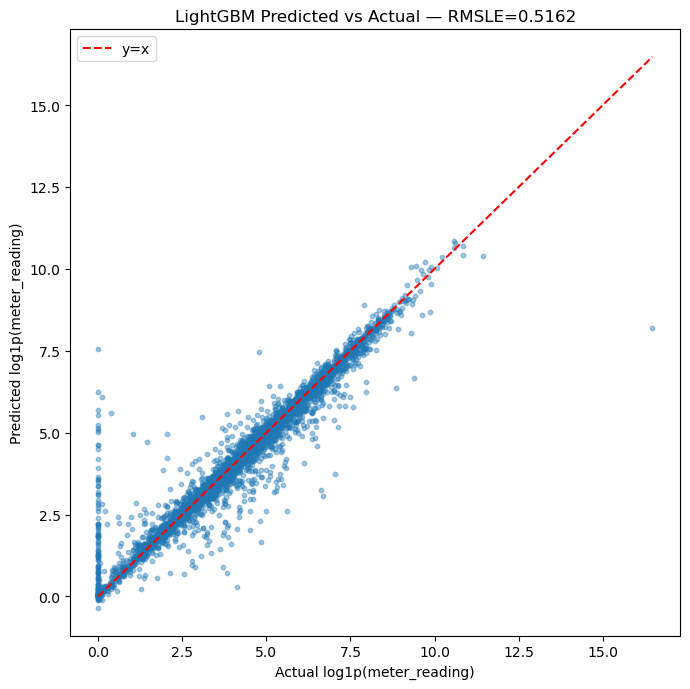

In [21]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), 5000, replace=False)
plt.figure(figsize=(7,7))
plt.scatter(np.log1p(y_test[idx]), np.log1p(y_pred[idx]), alpha=0.4, s=10)
m = max(np.log1p(y_test[idx]).max(), np.log1p(y_pred[idx]).max())
plt.plot([0,m],[0,m],'r--', label='y=x')
plt.xlabel('Actual log1p(meter_reading)')
plt.ylabel('Predicted log1p(meter_reading)')
plt.title(f'LightGBM Predicted vs Actual — RMSLE={rmsle_1:.4f}')
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/scatter_lightgbm_predicted_vs_actual.png', dpi=150)
plt.show()